###### Detection de fraude


################### FRAUD DETECTION


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Params OK
Loaded: (1000, 19)


,Assuré,Tiers,Contrat,N° Dossier,Expert,Observation,Date d'examen,Date d'accident,Marque,Puissance,Énergie,Couleur,Date 1ère mise en circulation,N° Série,Total M.O TTC,Total FOUR HT,Total Net,Désignations,Montants
0,Meriem Jebali,Fares Ben Youssef,CIO901098,2047935_550933837,Seif Ben Salah,Aucun écart significatif constaté.,05/06/2023,31/05/2023,Volkswagen,7 CV,ÉLECTRIQUE,Noir,02/11/2023,Vl5OMB8000Jin1Z,635.868,3501.000,4167.220,Capot moteur; Jante; Pare choc AV,579.39; 2358.124; 522.006
1,Asma Saidi,Ghofrane Baccar,CI44826,2096280_550338119,Imen Mansouri,Aucun écart significatif constaté.,27/05/2023,23/05/2023,Volkswagen,5 CV,GASOIL,Blanc,31/08/2024,1S9QYgFCukUK,1732.426,5204.633,6846.677,Produit de peinture; Jante; Grille inférieure,2572.288; 844.365; 1998.007
2,STAR Assurances,Dorsaf Jebali,CI0555N12407852,2082121_553619264,Ons Ben Aissa,"À notre avis, les dégâts constatés concordent ...",06/04/2024,06/04/2024,Dacia,10 CV,GASOIL,Bleu,06/08/2025,pRJfXYwPIkvB9,2386.276,15379.021,17651.306,Petites fournitures; Lunette AR; Feu AR; Grill...,1921.714; 457.328; 3293.232; 1899.624; 3428.97...


Mapped columns → 
CONTRAT: Contrat 
DOSSIER: N° Dossier 
OBS: Observation 
DATE_ACC: Date d'accident 
DATE_EX: Date d'examen 
DATE_MEC: Date 1ère mise en circulation 
MO: Total M.O TTC FOUR: Total FOUR HT NET: Total Net
Seuil (top 5%) = 0.5001 — weights: rules=0.6, text=0.3, algo=0.1


,Assuré,Tiers,Contrat,N° Dossier,Expert,Observation,Date d'examen,Date d'accident,Marque,Puissance,...,rule_intensity,text_anomaly,override_bloquant,rule_delai_accident_exam_gt_15j,rule_age_vehicule_extreme,rule_age_negatif,rule_montant_outlier,rule_ratio_incoherent,rule_multi_sinistres_contrat,rule_dossier_repete_dates_diff
0,Meriem Jebali,Fares Ben Youssef,CIO901098,2047935_550933837,Seif Ben Salah,Aucun écart significatif constaté.,05/06/2023,31/05/2023,Volkswagen,7 CV,...,0.285714,0.8805,0,0,1,1,0,0,0,0
1,Asma Saidi,Ghofrane Baccar,CI44826,2096280_550338119,Imen Mansouri,Aucun écart significatif constaté.,27/05/2023,23/05/2023,Volkswagen,5 CV,...,0.285714,0.8805,0,0,1,1,0,0,0,0
2,STAR Assurances,Dorsaf Jebali,CI0555N12407852,2082121_553619264,Ons Ben Aissa,"À notre avis, les dégâts constatés concordent ...",06/04/2024,06/04/2024,Dacia,10 CV,...,0.285714,0.3740,0,0,1,1,0,0,0,0
3,Hajar Gharbi,SNCFT,C10555N462191,2036758_558388568,Nesrine Ferchichi,Les relations entre les circonstances déclarée...,07/07/2025,06/07/2025,Peugeot,4 CV,...,0.000000,0.6340,0,0,0,0,0,0,0,0
4,Mohamed Boussetta,Farah Jebali,CC087920,2008339_552488967,Nadia Chouchene,Aucun écart significatif constaté.,12/04/2023,05/04/2023,Toyota,8 CV,...,0.285714,0.8805,0,0,1,1,0,0,0,0


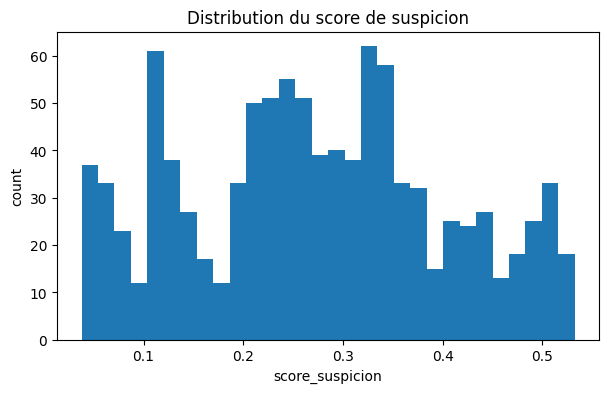

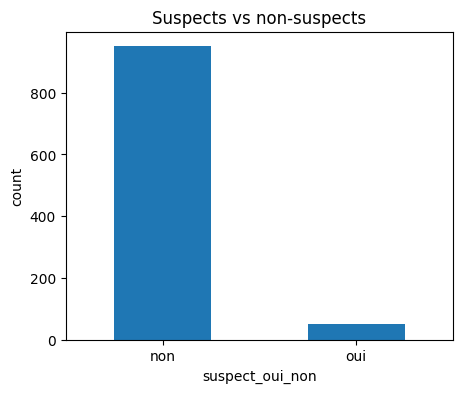

✅ Model saved to fraude_minimal_bundle.joblib
✅ Inference helpers ready

Demo predictions (3 rows):


,algo_if_score,score_suspicion,suspect_oui_non
0,0.523751,0.388095,non
1,0.521785,0.354762,non
2,0.558714,0.571429,oui


Numeric features used:


,delai_acc_exam_j,age_vehicule_ans_clean,Total M.O TTC,Total FOUR HT,Total Net,sum_mo_four,ratio_net_mo_four,net_z,multi_sinistres_win,dossier_total_lignes,dossier_dates_uniques,rule_delai_accident_exam_gt_15j,rule_age_vehicule_extreme,rule_age_negatif,rule_montant_outlier,rule_ratio_incoherent,rule_multi_sinistres_contrat,rule_dossier_repete_dates_diff
0,5,-0.424367,635.868,3501.000,4167.220,4136.868,1.007337,0.0,1.0,1.0,1.0,0,1,1,0,0,0,0
1,4,-1.275838,1732.426,5204.633,6846.677,6937.059,0.986971,0.0,1.0,1.0,1.0,0,1,1,0,0,0,0
2,0,-1.333333,2386.276,15379.021,17651.306,17765.297,0.993584,0.0,1.0,1.0,1.0,0,1,1,0,0,0,0


In [ ]:
# ============================================================
# FRAUDE AUTO — RULES-FIRST + NLP (keeps negative ages)
# Decision priority: Rules (60%) > Observation NLP (30%) > Algo (10%)
# Critical rules override the decision (force suspect)
# NLP: TF-IDF (FR stopwords via NLTK) + TruncatedSVD
# ============================================================

# 0) Imports & setup
import os, re, unicodedata, difflib, warnings
from datetime import datetime
import numpy as np
import pandas as pd

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.cluster import DBSCAN
from sklearn.feature_extraction.text import TfidfVectorizer

import matplotlib.pyplot as plt
from IPython.display import display
import joblib

warnings.filterwarnings("ignore")
np.random.seed(42)

# (Colab) mount Drive si dispo
try:
    from google.colab import drive, files
    drive.mount('/content/drive')
except Exception:
    pass

# 1) Params
EXCEL_PATH = "/content/drive/My Drive/sinistres.xlsx"   # <-- change if needed
TOP_PCT = 0.05                     # top 5% flagged by score (before overrides)
WINDOW_DAYS_MULTI = 60
DBSCAN_EPS = 1.6
DBSCAN_MIN_SAMPLES = 12
NLP_MAX_FEATURES = 8000
NLP_MIN_DF = 5
NLP_NCOMP = 100

# WEIGHTS (Rules > Text > Algo)
W_RULES = 0.60
W_TEXT  = 0.30
W_ALGO  = 0.10

# OUTPUT FILE NAMES (Excel optional, CSV removed)
OUT_FULL_XLSX = "sinistres_scored_minimal.xlsx"
OUT_SUS_XLSX  = "suspects_only_minimal.xlsx"
MODEL_PATH    = "fraude_minimal_bundle.joblib"

print("Params OK")

# 2) Utils
def norm(s):
    s = str(s)
    s = unicodedata.normalize("NFKD", s)
    s = "".join(ch for ch in s if not unicodedata.combining(ch))
    s = s.lower().strip()
    s = re.sub(r"[^a-z0-9]+", " ", s)
    return re.sub(r"\s+", " ", s).strip()

def best_match(df_cols, targets, cutoff=0.72):
    nc = {c: norm(c) for c in df_cols}
    for t in targets:
        tnorm = norm(t)
        for c, cn in nc.items():
            if cn == tnorm:
                return c
    all_norms = list(nc.values())
    for t in targets:
        tnorm = norm(t)
        got = difflib.get_close_matches(tnorm, all_norms, n=1, cutoff=cutoff)
        if got:
            for c, cn in nc.items():
                if cn == got[0]:
                    return c
    return None

def to_date(s):
    if pd.isna(s): return pd.NaT
    s = str(s).strip()
    for fmt in ("%d/%m/%Y", "%d-%m-%Y", "%Y-%m-%d", "%d/%m/%Y %H:%M:%S", "%Y-%m-%d %H:%M:%S"):
        try:
            return datetime.strptime(s, fmt)
        except:
            pass
    try:
        return pd.to_datetime(s, errors="coerce", dayfirst=True)
    except:
        return pd.NaT

def to_num(x):
    if pd.isna(x): return np.nan
    x = str(x).replace(",", ".")
    x = re.sub(r"[^0-9\.\-]", "", x)
    try:
        return float(x)
    except:
        return np.nan

def zscore_robuste(series):
    s = pd.to_numeric(series, errors="coerce").dropna()
    if len(s) < 10:
        return pd.Series(np.zeros(len(series)), index=series.index)
    med = s.median()
    mad = (s - med).abs().median()
    if mad == 0 or np.isnan(mad):
        return pd.Series(np.zeros(len(series)), index=series.index)
    z = (series - med) / (1.4826 * mad)
    z = z.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    return z

# 3) Load
assert os.path.exists(EXCEL_PATH), f"File not found: {EXCEL_PATH}"
try:
    df_raw = pd.read_excel(EXCEL_PATH)
except:
    df_raw = pd.read_csv(EXCEL_PATH, sep=",")
df_raw = df_raw.dropna(how="all")
print("Loaded:", df_raw.shape)
display(df_raw.head(3))

# 4) Auto-map headers
cols = list(df_raw.columns)

COL_ASSURE   = best_match(cols, ["Assuré","Assure","Assuré"])
COL_TIERS    = best_match(cols, ["Tiers"])
COL_CONTRAT  = best_match(cols, ["Contrat","N° Contrat","No Contrat","Numero contrat","Numéro contrat","N Contrat","N° de Contrat"])
COL_DOSSIER  = best_match(cols, ["N° Dossier","No Dossier","Numero dossier","Numéro dossier","Dossier","N dossier","Num dossier"])
COL_EXPERT   = best_match(cols, ["Expert"])
COL_OBS      = best_match(cols, ["Observation","Observations","Commentaire","Commentaires"])
COL_DATE_EX  = best_match(cols, ["Date d'examen","Date examen","Date d’examen","Date_examen"])
COL_DATE_ACC = best_match(cols, ["Date d'accident","Date accident","Date d’accident","Date_accident","date sinistre","date_sinistre"])
COL_MARQUE   = best_match(cols, ["Marque"])
COL_PUI      = best_match(cols, ["Puissance"])
COL_ENERGIE  = best_match(cols, ["Énergie","Energie"])
COL_COULEUR  = best_match(cols, ["Couleur"])
COL_DATE_MEC = best_match(cols, ["Date 1ère mise en circulation","Date 1ere mise en circulation","Date mise en circulation","Date_1ere_mise_en_circulation","Date MEC","mise en circulation"])
COL_NUM_SER  = best_match(cols, ["N° Série","No Série","Numero de serie","N Serie"])

COL_MO       = best_match(cols, ["Total M.O TTC","Total MO TTC","Total_MO_TTC"])
COL_FOUR     = best_match(cols, ["Total FOUR HT","Total_FOUR_HT","Total Fournitures HT","Total F.H.T"])
COL_NET      = best_match(cols, ["Total Net","Total_Net","TotalNet"])

print("Mapped columns →",
      "\nCONTRAT:", COL_CONTRAT,
      "\nDOSSIER:", COL_DOSSIER,
      "\nOBS:", COL_OBS,
      "\nDATE_ACC:", COL_DATE_ACC,
      "\nDATE_EX:", COL_DATE_EX,
      "\nDATE_MEC:", COL_DATE_MEC,
      "\nMO:", COL_MO, "FOUR:", COL_FOUR, "NET:", COL_NET)

# 5) Feature engineering (robuste)
df = df_raw.copy()

# Dates
df["date_accident"] = df[COL_DATE_ACC].apply(to_date) if COL_DATE_ACC else pd.NaT
df["date_examen"]   = df[COL_DATE_EX].apply(to_date)  if COL_DATE_EX  else pd.NaT
df["date_mec"]      = df[COL_DATE_MEC].apply(to_date) if COL_DATE_MEC else pd.NaT

# Délai accident -> examen (jours)
df["delai_acc_exam_j"] = (df["date_examen"] - df["date_accident"]).dt.days \
                         if (COL_DATE_ACC and COL_DATE_EX) else np.nan

# Âge véhicule (années) + NEG flag (KEEP NEGATIVES)
df["age_vehicule_ans"] = np.where(
    df["date_mec"].notna() & df["date_accident"].notna(),
    (df["date_accident"] - df["date_mec"]).dt.days / 365.25,
    np.nan
)
df["rule_age_negatif"] = df["age_vehicule_ans"].apply(lambda a: 1 if pd.notna(a) and a < 0 else 0)
df["age_vehicule_ans_clean"] = df["age_vehicule_ans"]  # <-- keep negatives

# Montants -> numériques
for c in [COL_MO, COL_FOUR, COL_NET]:
    if c:
        df[c] = df[c].apply(to_num)

df["sum_mo_four"] = np.where(
    (COL_MO is not None) & (COL_FOUR is not None),
    df.get(COL_MO, np.nan).fillna(0) + df.get(COL_FOUR, np.nan).fillna(0),
    np.nan
)
df["ratio_net_mo_four"] = np.where(
    df["sum_mo_four"].notna() & (df["sum_mo_four"] != 0) & (COL_NET is not None),
    df.get(COL_NET, np.nan) / df["sum_mo_four"],
    np.nan
)

# Stats dossier
if COL_DOSSIER:
    total_lignes = df.groupby(COL_DOSSIER).size().rename("dossier_total_lignes").reset_index()
    if "date_accident" in df.columns:
        uniq_dates = (
            df.loc[df["date_accident"].notna(), [COL_DOSSIER, "date_accident"]]
              .groupby(COL_DOSSIER)["date_accident"].nunique()
              .rename("dossier_dates_uniques").reset_index()
        )
    else:
        uniq_dates = pd.DataFrame(columns=[COL_DOSSIER, "dossier_dates_uniques"])
    df = df.merge(total_lignes, how="left", on=COL_DOSSIER)
    df = df.merge(uniq_dates,  how="left", on=COL_DOSSIER)
    df["dossier_dates_uniques"] = df["dossier_dates_uniques"].fillna(0).astype(int)
    df["flag_dossier_repete_dates_diff"] = (df["dossier_dates_uniques"] > 1).astype(int)
else:
    df["dossier_total_lignes"] = np.nan
    df["dossier_dates_uniques"] = np.nan
    df["flag_dossier_repete_dates_diff"] = np.nan

# Multi-sinistres (rolling 60j par Contrat)
if (COL_CONTRAT is not None) and ("date_accident" in df.columns):
    tmp = (df[[COL_CONTRAT, "date_accident"]]
           .dropna()
           .sort_values("date_accident")
           .set_index("date_accident")
           .copy())
    if not tmp.empty:
        tmp["ones"] = 1.0
        rc = (tmp.groupby(COL_CONTRAT)["ones"]
                 .rolling(f"{WINDOW_DAYS_MULTI}D", min_periods=1)
                 .sum()
                 .reset_index()
                 .rename(columns={"ones":"multi_sinistres_win"}))
        df = df.merge(rc, how="left", on=[COL_CONTRAT, "date_accident"])
        mask_isolated = df[COL_CONTRAT].notna() & df["date_accident"].notna() & df["multi_sinistres_win"].isna()
        df.loc[mask_isolated, "multi_sinistres_win"] = 1.0
    else:
        df["multi_sinistres_win"] = np.nan
else:
    df["multi_sinistres_win"] = np.nan

# Z-score NET (robuste)
if (COL_NET is not None) and (COL_NET in df.columns):
    if df[COL_NET].notna().sum() > 10 and (df[COL_NET].std(ddof=0) or 0) > 0:
        mu = df[COL_NET].mean(); sd = df[COL_NET].std(ddof=0)
        df["net_z"] = (df[COL_NET] - mu) / sd
    else:
        df["net_z"] = zscore_robuste(df[COL_NET])
else:
    df["net_z"] = 0.0

# 6) Rules (0/1)
rule_cols = []

if "delai_acc_exam_j" in df.columns:
    df["rule_delai_accident_exam_gt_15j"] = df["delai_acc_exam_j"].apply(lambda x: 1 if pd.notna(x) and x > 15 else 0)
    rule_cols.append("rule_delai_accident_exam_gt_15j")
else:
    df["rule_delai_accident_exam_gt_15j"] = 0

if "age_vehicule_ans" in df.columns:
    df["rule_age_vehicule_extreme"] = df["age_vehicule_ans"].apply(
        lambda a: 1 if (pd.notna(a) and ((a < (30/365.25)) or (a > 20))) else 0
    )
    rule_cols.append("rule_age_vehicule_extreme")
else:
    df["rule_age_vehicule_extreme"] = 0

if "rule_age_negatif" in df.columns:
    rule_cols.append("rule_age_negatif")
else:
    df["rule_age_negatif"] = 0

if "net_z" in df.columns:
    df["rule_montant_outlier"] = df["net_z"].apply(lambda z: 1 if abs(float(z)) >= 3 else 0)
    rule_cols.append("rule_montant_outlier")
else:
    df["rule_montant_outlier"] = 0

if ("sum_mo_four" in df.columns) and (COL_NET is not None):
    df["rule_ratio_incoherent"] = np.where(
        df["sum_mo_four"].notna() & df.get(COL_NET, pd.Series(dtype=float)).notna(),
        (df[COL_NET] > 1.5 * df["sum_mo_four"]).astype(int),
        0
    )
    rule_cols.append("rule_ratio_incoherent")
else:
    df["rule_ratio_incoherent"] = 0

if "multi_sinistres_win" in df.columns:
    df["rule_multi_sinistres_contrat"] = df["multi_sinistres_win"].apply(lambda x: 1 if pd.notna(x) and x >= 3 else 0)
    rule_cols.append("rule_multi_sinistres_contrat")
else:
    df["rule_multi_sinistres_contrat"] = 0

if "flag_dossier_repete_dates_diff" in df.columns:
    df["rule_dossier_repete_dates_diff"] = df["flag_dossier_repete_dates_diff"].fillna(0).astype(int)
    rule_cols.append("rule_dossier_repete_dates_diff")
else:
    df["rule_dossier_repete_dates_diff"] = 0

def motif_rules(row):
    hits = [c for c in rule_cols if row.get(c, 0) == 1]
    return "; ".join(hits)
df["motifs_suspicion_regles"] = df.apply(motif_rules, axis=1)

# 7) Numeric feature list
num_base_feats = [
    "delai_acc_exam_j", "age_vehicule_ans_clean",
    COL_MO if COL_MO else None,
    COL_FOUR if COL_FOUR else None,
    COL_NET if COL_NET else None,
    "sum_mo_four", "ratio_net_mo_four", "net_z",
    "multi_sinistres_win", "dossier_total_lignes", "dossier_dates_uniques"
]
num_base_feats = [c for c in num_base_feats if c and c in df.columns]
num_rule_feats = rule_cols.copy()
num_feature_cols = [c for c in num_base_feats + num_rule_feats if c in df.columns]
if not num_feature_cols:
    df["dummy_zero"] = 0.0
    num_feature_cols = ["dummy_zero"]

# 8) NLP (Observation) TF-IDF FR via NLTK -> SVD
french_stop = None
if COL_OBS:
    try:
        import nltk
        try:
            from nltk.corpus import stopwords
            _ = stopwords.words("french")
        except LookupError:
            nltk.download("stopwords")
        from nltk.corpus import stopwords
        french_stop = stopwords.words("french")
    except Exception as e:
        print("⚠️ NLTK stopwords unavailable, proceeding without stop words.", e)
        french_stop = None

vectorizer, svd, X_text = None, None, None
if COL_OBS:
    texts = df[COL_OBS].astype(str).fillna("")
    vectorizer = TfidfVectorizer(
        lowercase=True,
        strip_accents="unicode",
        ngram_range=(1,2),
        min_df=NLP_MIN_DF,
        max_features=NLP_MAX_FEATURES,
        stop_words=french_stop
    )
    X_tfidf = vectorizer.fit_transform(texts)
    safe_features = max(1, X_tfidf.shape[1] - 1)
    ncomp = int(min(NLP_NCOMP, safe_features))
    svd = TruncatedSVD(n_components=ncomp, random_state=42)
    X_text = svd.fit_transform(X_tfidf)

# 9) Preprocess numeric + concat NLP
preproc_num = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
X_num = df[num_feature_cols].copy()
X_num_proc = preproc_num.fit_transform(X_num)

if X_text is not None and X_text.shape[0] == X_num_proc.shape[0]:
    X_all = np.hstack([X_num_proc, X_text])
else:
    X_all = X_num_proc

# 10) IsolationForest (+ optional DBSCAN for aux signal)
iso = IsolationForest(
    n_estimators=300, max_samples="auto", contamination="auto",
    random_state=42, n_jobs=-1
).fit(X_all)
if_scores = -iso.score_samples(X_all)  # higher = more suspicious

try:
    pca = PCA(n_components=min(5, X_all.shape[1]), random_state=42)
    X_pca = pca.fit_transform(X_all)
    db = DBSCAN(eps=DBSCAN_EPS, min_samples=DBSCAN_MIN_SAMPLES, n_jobs=-1)
    db_labels = db.fit_predict(X_pca)
    db_flag = (db_labels == -1).astype(int)
except Exception:
    pca, db, db_labels = None, None, np.zeros(len(df), dtype=int)
    db_flag = db_labels

# 11) RULES-FIRST SCORING
# (1) Rules intensity
if len(rule_cols) > 0:
    rule_matrix = df[rule_cols].fillna(0).values
    rule_intensity = (rule_matrix.sum(axis=1) / float(len(rule_cols)))
else:
    rule_intensity = np.zeros(df.shape[0])

# (2) Text anomaly (0..1) from SVD z-magnitude mean, ranked
text_anom = np.zeros(df.shape[0])
if X_text is not None:
    mu_t = X_text.mean(axis=0, keepdims=True)
    sd_t = X_text.std(axis=0, keepdims=True); sd_t[sd_t == 0] = 1.0
    Z = (X_text - mu_t) / sd_t
    text_raw = np.mean(np.abs(Z), axis=1)
    text_anom = pd.Series(text_raw).rank(pct=True).values

# (3) Algo anomaly (IF rank + small DB flag)
if_rank = pd.Series(if_scores).rank(pct=True).values
algo_anom = 0.9 * if_rank + 0.1 * db_flag

# (4) Weighted score
score_suspicion = W_RULES * rule_intensity + W_TEXT * text_anom + W_ALGO * algo_anom

# (5) Blocking overrides (critical rules)
critical_rules = [
    "rule_dossier_repete_dates_diff",
    "rule_multi_sinistres_contrat",
    "rule_ratio_incoherent",
]
critical_rules = [r for r in critical_rules if r in df.columns]
override_bloquant = np.zeros(df.shape[0], dtype=int)
if len(critical_rules) > 0:
    override_bloquant = (df[critical_rules].fillna(0).sum(axis=1) > 0).astype(int)

# (6) Threshold + override decision
threshold = np.quantile(score_suspicion, 1 - TOP_PCT)
suspect = ((score_suspicion >= threshold) | (override_bloquant == 1)).astype(int)

# 12) Outputs (no CSV; Excel optional)
df_out = df_raw.copy()
df_out["score_suspicion"] = score_suspicion
df_out["suspect_oui_non"] = np.where(suspect == 1, "oui", "non")
df_out["algo_if_score"]   = if_scores
df_out["dbscan_label"]    = db_labels
df_out["motifs_suspicion_regles"] = df["motifs_suspicion_regles"]
df_out["rule_intensity"]  = rule_intensity
df_out["text_anomaly"]    = text_anom
df_out["override_bloquant"] = override_bloquant
for c in rule_cols:
    df_out[c] = df[c] if c in df else 0

print(f"Seuil (top {int(TOP_PCT*100)}%) = {threshold:.4f} — "
      f"weights: rules={W_RULES}, text={W_TEXT}, algo={W_ALGO}")
display(df_out.head(5))

# Optional: save to Excel (uncomment if you want files)
# df_out.to_excel(OUT_FULL_XLSX, index=False)
# sus_only = df_out.loc[df_out["suspect_oui_non"] == "oui"].copy()
# sus_only.to_excel(OUT_SUS_XLSX, index=False)
# try:
#     files.download(OUT_FULL_XLSX)
#     files.download(OUT_SUS_XLSX)
# except Exception:
#     pass

# 13) Quick viz
plt.figure(figsize=(7,4))
plt.hist(df_out["score_suspicion"], bins=30)
plt.title("Distribution du score de suspicion")
plt.xlabel("score_suspicion"); plt.ylabel("count")
plt.show()

plt.figure(figsize=(5,4))
df_out["suspect_oui_non"].value_counts().plot(kind="bar", rot=0)
plt.title("Suspects vs non-suspects")
plt.ylabel("count")
plt.show()

# 14) Save model bundle (incl. text pipeline & weights)
bundle = {
    "num_feature_cols": num_feature_cols,
    "preproc_num": preproc_num,
    "vectorizer": vectorizer,
    "svd": svd,
    "isolation_forest": iso,
    "weights": {"rules": W_RULES, "text": W_TEXT, "algo": W_ALGO},
    "top_pct": float(TOP_PCT),
    "threshold": float(threshold),
    "rule_cols": rule_cols,
    "critical_rules": critical_rules,
    "columns_used": {
        "observation": COL_OBS,
        "date_accident": COL_DATE_ACC,
        "date_examen": COL_DATE_EX,
        "date_mec": COL_DATE_MEC,
        "mo": COL_MO,
        "four": COL_FOUR,
        "net": COL_NET,
        "contrat": COL_CONTRAT,
        "dossier": COL_DOSSIER
    }
}
if 'pca' in locals() and pca is not None: bundle["pca"] = pca
if 'db'  in locals() and db  is not None: bundle["dbscan"] = db

joblib.dump(bundle, MODEL_PATH)
print("✅ Model saved to", MODEL_PATH)

# 15) Inference helpers (keeps negative ages & fixes delay name)
def build_features_numeric(new_df, bundle):
    C = bundle["columns_used"]
    out = new_df.copy()

    # dates
    out["date_accident"] = out[C["date_accident"]].apply(to_date) if C["date_accident"] in out.columns else pd.NaT
    out["date_examen"]   = out[C["date_examen"]].apply(to_date)   if C["date_examen"]   in out.columns else pd.NaT
    out["date_mec"]      = out[C["date_mec"]].apply(to_date)      if C["date_mec"]      in out.columns else pd.NaT

    # delay
    out["delai_acc_exam_j"] = (out["date_examen"] - out["date_accident"]).dt.days
    # defensive alias in case of accidental column name elsewhere
    if "delai_accident_exam_j" in out.columns and "delai_acc_exam_j" not in out.columns:
        out["delai_acc_exam_j"] = out["delai_accident_exam_j"]

    # age (keep negatives)
    out["age_vehicule_ans"] = np.where(
        out["date_mec"].notna() & out["date_accident"].notna(),
        (out["date_accident"] - out["date_mec"]).dt.days / 365.25,
        np.nan
    )
    out["rule_age_negatif"] = out["age_vehicule_ans"].apply(lambda a: 1 if pd.notna(a) and a < 0 else 0)
    out["age_vehicule_ans_clean"] = out["age_vehicule_ans"]

    # montants
    if C["mo"] in out.columns:   out[C["mo"]]   = out[C["mo"]].apply(to_num)
    if C["four"] in out.columns: out[C["four"]] = out[C["four"]].apply(to_num)
    if C["net"] in out.columns:  out[C["net"]]  = out[C["net"]].apply(to_num)

    out["sum_mo_four"] = np.where(
        (C["mo"] in out.columns) & (C["four"] in out.columns),
        out.get(C["mo"], np.nan).fillna(0) + out.get(C["four"], np.nan).fillna(0),
        np.nan
    )
    out["ratio_net_mo_four"] = np.where(
        (out["sum_mo_four"].notna()) & (out["sum_mo_four"] != 0) & (C["net"] in out.columns),
        out[C["net"]] / out["sum_mo_four"],
        np.nan
    )

    # no history at single-row inference → conservative defaults
    out["multi_sinistres_win"] = 1.0
    out["dossier_total_lignes"] = 1.0
    out["dossier_dates_uniques"] = np.where(out["date_accident"].notna(), 1.0, 0.0)

    # rules (recompute) — IMPORTANT: use the correct delay name here
    out["rule_delai_accident_exam_gt_15j"] = out["delai_acc_exam_j"].apply(lambda x: 1 if pd.notna(x) and x > 15 else 0)
    out["rule_age_vehicule_extreme"] = out["age_vehicule_ans"].apply(
        lambda a: 1 if (pd.notna(a) and ((a < (30/365.25)) or (a > 20))) else 0
    )
    out["rule_montant_outlier"] = 0
    out["rule_ratio_incoherent"] = np.where(
        (out["sum_mo_four"].notna()) & (C["net"] in out.columns),
        (out[C["net"]] > 1.5 * out["sum_mo_four"]).astype(int),
        0
    )
    out["rule_multi_sinistres_contrat"] = 0
    out["rule_dossier_repete_dates_diff"] = 0

    out["net_z"] = 0.0

    need = bundle["num_feature_cols"]
    for c in need:
        if c not in out.columns:
            out[c] = np.nan
    return out[need]

def build_features_text(new_df, bundle):
    col_obs = bundle["columns_used"]["observation"]
    vec = bundle.get("vectorizer", None)
    svd = bundle.get("svd", None)
    if col_obs is None or vec is None or svd is None or (col_obs not in new_df.columns):
        return None
    texts = new_df[col_obs].astype(str).fillna("")
    X_tfidf = vec.transform(texts)
    X_text  = svd.transform(X_tfidf)
    return X_text

def predict_from_raw_minimal(new_raw_df, bundle):
    # numeric
    X_num = build_features_numeric(new_raw_df.copy(), bundle)
    X_num_proc = bundle["preproc_num"].transform(X_num)

    # text
    X_text = build_features_text(new_raw_df.copy(), bundle)
    if X_text is not None and X_text.shape[0] == X_num_proc.shape[0]:
        X_all = np.hstack([X_num_proc, X_text])
    else:
        X_all = X_num_proc

    # algo anomaly
    if_score = -bundle["isolation_forest"].score_samples(X_all)
    if_rank = pd.Series(if_score).rank(pct=True).values

    # text anomaly (ranked z-magnitude)
    if X_text is not None:
        mu_t = X_text.mean(axis=0, keepdims=True)
        sd_t = X_text.std(axis=0, keepdims=True); sd_t[sd_t == 0] = 1.0
        Z = (X_text - mu_t) / sd_t
        text_raw = np.mean(np.abs(Z), axis=1)
        text_anom = pd.Series(text_raw).rank(pct=True).values
    else:
        text_anom = np.zeros(X_all.shape[0])

    # rules intensity
    rule_cols = bundle.get("rule_cols", [])
    if len(rule_cols) > 0 and all(c in X_num.columns for c in rule_cols):
        rule_matrix = X_num[rule_cols].fillna(0).values
        rule_intensity = (rule_matrix.sum(axis=1) / float(len(rule_cols)))
    else:
        rule_intensity = np.zeros(X_all.shape[0])

    # weighted score (no DBSCAN at inference)
    W = bundle.get("weights", {"rules":0.60, "text":0.30, "algo":0.10})
    score_susp = W["rules"]*rule_intensity + W["text"]*text_anom + W["algo"]*if_rank

    # override
    crit = bundle.get("critical_rules", [])
    if len(crit) > 0 and all(c in X_num.columns for c in crit):
        override = (X_num[crit].fillna(0).sum(axis=1) > 0).astype(int).values
    else:
        override = np.zeros(X_all.shape[0], dtype=int)

    pred = pd.DataFrame({
        "algo_if_score": if_score,
        "score_suspicion": score_susp,
        "suspect_oui_non": np.where((score_susp >= bundle["threshold"]) | (override == 1), "oui", "non")
    })
    return pred, X_num

print("✅ Inference helpers ready")

# 16) Mini demo (first 3 rows)
bundle_loaded = joblib.load(MODEL_PATH)
demo_rows = df_raw.head(3).copy()
pred_demo, used_feats = predict_from_raw_minimal(demo_rows, bundle_loaded)
print("\nDemo predictions (3 rows):")
display(pred_demo)
print("Numeric features used:")
display(used_feats.head(3))


In [ ]:
import random

def test_random_row_from_excel(excel_path, model_path="fraude_minimal_bundle.joblib"):
    # Load the model bundle
    bundle = joblib.load(model_path)

    # Load the Excel
    df_in = pd.read_excel(excel_path).dropna(how="all")

    # Pick one random row
    idx = random.choice(df_in.index.tolist())
    row = df_in.loc[[idx]].copy()   # keep as DataFrame (not Series)

    # Predict
    pred, feats = predict_from_raw_minimal(row, bundle)

    print(f"🎯 Testing row #{idx}")
    display(row)
    display(pred)
    return row, pred

# === Example usage ===
row, pred = test_random_row_from_excel(EXCEL_PATH)


🎯 Testing row #553


,Assuré,Tiers,Contrat,N° Dossier,Expert,Observation,Date d'examen,Date d'accident,Marque,Puissance,Énergie,Couleur,Date 1ère mise en circulation,N° Série,Total M.O TTC,Total FOUR HT,Total Net,Désignations,Montants
553,Mouna Sassi,Ameni Ben Salah,CC956466,2067644_554967056,Hajar Saidi,Choc concordant à la déclaration.,24/05/2024,12/05/2024,Toyota,5 CV,ESSENCE,Jaune taxi,20/03/2023,cHa7aUckxgvZJyt,2156.839,839.287,3109.466,Vitre,881.595


,algo_if_score,score_suspicion,suspect_oui_non
0,0.557617,0.4,non
